In [2]:
# Cell 5: Installation
!pip install -q qiskit qiskit-aer matplotlib pandas midiutil
!apt-get install -qq fluidsynth
!pip install -q midi2audio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.3 MB/s eta 0:00:00
Extracting templates from packages: 100%
Selecting previously unselected package libdouble-conversion3:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../00-libdouble-conversion3_3.1.7-4_amd64.deb ...
Unpacking libdouble-conversion3:amd64 (3.1.7-4) ...
Selecting previously unselected package libqt5core5a:amd64.
Preparing to unpack .../01-libqt5core5a_5.15.3+dfsg-2ubuntu0.2_amd64.deb ...
Unpacking libqt5core5a:amd64 (5.15.3+dfsg-2ubuntu0.2) ...
Selecting previously unselected package libevdev2:amd64.
Preparing to

In [23]:
# Cell 6: Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# MIDI and audio
from midiutil import MIDIFile
from midi2audio import FluidSynth

# IPython display
from IPython.display import Audio, display

# System
import os
import time

In [24]:
# Cell 7: Configuration – change these to alter the musical output

# Quantum settings
NUM_QUBITS = 11               # bits per note (see mapping below)
SHOTS = 32                    # number of notes (measurements)
SIMULATOR_SEED = None         # set an integer for reproducible "quantum" outcomes (only for simulators)

# Musical settings
TEMPO = 100                   # beats per minute
TIME_SIGNATURE = (4, 4)       # not used in MIDI but kept for reference
ROOT_NOTE = 'C'               # C, D, E, ...
SCALE_TYPE = 'major'          # 'major', 'minor', 'pentatonic_major', 'pentatonic_minor'
BASE_OCTAVE = 4               # middle C = C4
OCTAVE_RANGE = 3              # number of octaves above base (0,1,2,3) – controlled by 2 bits

# Duration options (in beats)
DURATIONS = [0.25, 0.5, 1.0, 2.0]   # sixteenth, eighth, quarter, half

# Velocity range (MIDI velocity 0–127)
VELOCITY_MIN = 60
VELOCITY_MAX = 100

# Rest probability (controlled by 1 bit: 1 = rest, 0 = play)
# The bit is a direct 0/1, so rest probability is ~50% per note.
# You can override by treating the rest bit differently; we keep it as is.

# Output
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Quantum Randomness – Circuit

We build a circuit with `NUM_QUBITS` qubits. Each qubit is initialised in |0⟩, then a Hadamard gate is applied, creating the equal superposition state. Finally each qubit is measured.

Because measurements are independent, each shot yields a random bitstring of length `NUM_QUBITS`. Repeated shots produce a list of bitstrings – our raw quantum data.

In [25]:
# Cell 9: Build the Quantum Circuit
qc = QuantumCircuit(NUM_QUBITS, NUM_QUBITS)

# Apply Hadamard to all qubits
for i in range(NUM_QUBITS):
    qc.h(i)

# Measure all qubits
qc.measure(range(NUM_QUBITS), range(NUM_QUBITS))

# Display the circuit
print("Circuit:")
print(qc.draw())

Circuit:
      ┌───┐┌─┐                              
 q_0: ┤ H ├┤M├──────────────────────────────
      ├───┤└╥┘┌─┐                           
 q_1: ┤ H ├─╫─┤M├───────────────────────────
      ├───┤ ║ └╥┘┌─┐                        
 q_2: ┤ H ├─╫──╫─┤M├────────────────────────
      ├───┤ ║  ║ └╥┘┌─┐                     
 q_3: ┤ H ├─╫──╫──╫─┤M├─────────────────────
      ├───┤ ║  ║  ║ └╥┘┌─┐                  
 q_4: ┤ H ├─╫──╫──╫──╫─┤M├──────────────────
      ├───┤ ║  ║  ║  ║ └╥┘┌─┐               
 q_5: ┤ H ├─╫──╫──╫──╫──╫─┤M├───────────────
      ├───┤ ║  ║  ║  ║  ║ └╥┘┌─┐            
 q_6: ┤ H ├─╫──╫──╫──╫──╫──╫─┤M├────────────
      ├───┤ ║  ║  ║  ║  ║  ║ └╥┘┌─┐         
 q_7: ┤ H ├─╫──╫──╫──╫──╫──╫──╫─┤M├─────────
      ├───┤ ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐      
 q_8: ┤ H ├─╫──╫──╫──╫──╫──╫──╫──╫─┤M├──────
      ├───┤ ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐   
 q_9: ┤ H ├─╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├───
      ├───┤ ║  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐
q_10: ┤ H ├─╫──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├
 

In [26]:
# Cell 10: Run the Quantum Experiment
simulator = AerSimulator()
# Transpile for simulator (optional but good practice)
transpiled_circuit = transpile(qc, simulator)
# Set seed if provided
if SIMULATOR_SEED is not None:
    simulator.set_options(seed_simulator=SIMULATOR_SEED)

# Execute
job = simulator.run(transpiled_circuit, shots=SHOTS)
result = job.result()
counts = result.get_counts()

# Extract bitstrings (each is a string of length NUM_QUBITS, e.g., '010110...')
bitstrings = list(counts.keys())
# Expand based on counts to get a list of individual bitstrings (one per shot)
expanded_bitstrings = []
for bs, count in counts.items():
    expanded_bitstrings.extend([bs] * count)

# If due to probability, we may have fewer than SHOTS unique bitstrings; we take the first SHOTS
expanded_bitstrings = expanded_bitstrings[:SHOTS]

print(f"Total shots: {SHOTS}")
print(f"Unique bitstrings: {len(counts)}")
print("First 10 bitstrings:", expanded_bitstrings[:10])

Total shots: 32
Unique bitstrings: 30
First 10 bitstrings: ['00110110110', '10010001111', '11100010110', '10001010100', '10000011101', '10000011101', '10100011011', '00011010110', '11010011000', '10011111110']


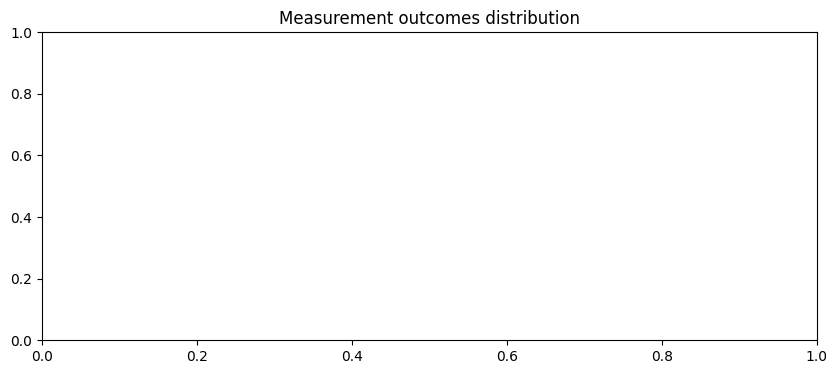

In [27]:
# Cell 11: Visualise Measurement Distribution
plt.figure(figsize=(10, 4))
plot_histogram(counts, figsize=(10, 4))
plt.title("Measurement outcomes distribution")
plt.show()

## From Bits to Music

We interpret the `NUM_QUBITS` bits of each shot as follows:

| Bits           | Parameter      | Interpretation |
|----------------|----------------|----------------|
| **0**          | Rest           | 0 = play, 1 = rest |
| **1–3**        | Scale degree   | 0–6 → scale notes (C–B in major), 7 → unused (treated as scale degree 0) |
| **4–5**        | Octave offset  | 0–3 → adds to `BASE_OCTAVE` |
| **6–7**        | Duration index | 0–3 → selects from `DURATIONS` list |
| **8–10**       | Velocity index | 0–7 → maps linearly to `VELOCITY_MIN`–`VELOCITY_MAX` |

This mapping is deterministic: the same bitstring always produces the same musical parameters. Only the quantum measurement introduces variation.

In [28]:
# Cell 13: Musical Theory Configuration

# Define scales as semitone offsets from root
SCALES = {
    'major': [0, 2, 4, 5, 7, 9, 11],
    'minor': [0, 2, 3, 5, 7, 8, 10],
    'pentatonic_major': [0, 2, 4, 7, 9],
    'pentatonic_minor': [0, 3, 5, 7, 10],
}

# Root note mapping (MIDI note number for C4 = 60, D4 = 62, etc.)
NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
ROOT_OFFSET = NOTE_NAMES.index(ROOT_NOTE)   # semitones above C

# Get scale offsets
scale_offsets = SCALES[SCALE_TYPE]
num_scale_degrees = len(scale_offsets)      # e.g., 7 for major

# Precompute MIDI note numbers for each scale degree and octave
def get_midi_note(degree, octave_offset):
    # degree: 0..num_scale_degrees-1; octave_offset: 0..3
    semitone = ROOT_OFFSET + scale_offsets[degree % num_scale_degrees]
    octave = BASE_OCTAVE + octave_offset
    midi = 12 * octave + semitone
    return midi

# Example: C major, degree 0 (C) at octave 4 -> 60
print(f"Root: {ROOT_NOTE}, Scale: {SCALE_TYPE}")
print(f"Scale degrees (semitones above root): {scale_offsets}")
print(f"Example: degree 0, octave 0 -> MIDI {get_midi_note(0, 0)}")

Root: C, Scale: major
Scale degrees (semitones above root): [0, 2, 4, 5, 7, 9, 11]
Example: degree 0, octave 0 -> MIDI 48


In [29]:
# Cell 14: Bitstream Generator (already run above)
# The bitstrings are stored in expanded_bitstrings.
# We'll keep them as a list of strings.
def get_quantum_bitstream():
    """Return the list of bitstrings obtained from the quantum circuit."""
    return expanded_bitstrings

In [30]:
# Cell 15: Bitstring → Integer
def bits_to_int(bits):
    """Convert a string of 0/1 to an integer (most significant bit first)."""
    return int(bits, 2)

# Example
print(bits_to_int('101') == 5)

True


In [31]:
# Cell 16: Quantum Bits → Musical Parameters
def bitstring_to_note_params(bitstring):
    """
    Convert an 11‑bit string to a dictionary of musical parameters.
    """
    if len(bitstring) != NUM_QUBITS:
        raise ValueError(f"Expected {NUM_QUBITS} bits, got {len(bitstring)}")

    # Extract bits (MSB first: bit 0 is the first character)
    rest_bit = int(bitstring[0])
    pitch_bits = bitstring[1:4]   # 3 bits
    octave_bits = bitstring[4:6]  # 2 bits
    dur_bits = bitstring[6:8]     # 2 bits
    vel_bits = bitstring[8:11]    # 3 bits

    # Convert to integers
    pitch_idx = bits_to_int(pitch_bits) % num_scale_degrees   # safe: 0..6 for major
    octave_offset = bits_to_int(octave_bits)                  # 0..3
    dur_idx = bits_to_int(dur_bits) % len(DURATIONS)          # 0..3
    vel_idx = bits_to_int(vel_bits)                           # 0..7

    # Compute MIDI pitch
    midi_pitch = get_midi_note(pitch_idx, octave_offset) if rest_bit == 0 else None

    # Duration in beats
    duration = DURATIONS[dur_idx]

    # Velocity: map 0..7 to VELOCITY_MIN..VELOCITY_MAX
    velocity = int(VELOCITY_MIN + (VELOCITY_MAX - VELOCITY_MIN) * (vel_idx / 7.0))

    return {
        'rest': bool(rest_bit),
        'midi_pitch': midi_pitch,
        'duration': duration,
        'velocity': velocity,
        'bitstring': bitstring,
        'pitch_idx': pitch_idx if rest_bit == 0 else None,
        'octave_offset': octave_offset,
        'dur_idx': dur_idx,
        'vel_idx': vel_idx,
    }

In [32]:
# Cell 17: Generate Melody
def generate_quantum_melody(bitstrings):
    """
    Given a list of bitstrings, produce a list of note dictionaries.
    """
    melody = []
    for bs in bitstrings:
        params = bitstring_to_note_params(bs)
        melody.append(params)
    return melody

# Generate
melody_data = generate_quantum_melody(expanded_bitstrings)
print(f"Generated {len(melody_data)} notes (including rests).")

Generated 32 notes (including rests).


In [33]:
# Cell 18: Display Generated Composition
def note_name_from_midi(midi):
    if midi is None:
        return 'REST'
    octave = midi // 12
    note = NOTE_NAMES[midi % 12]
    return f"{note}{octave}"

# Build a DataFrame for viewing
rows = []
for i, note in enumerate(melody_data):
    row = {
        'Index': i,
        'Bitstring': note['bitstring'],
        'Rest': note['rest'],
        'Note': note_name_from_midi(note['midi_pitch']) if not note['rest'] else 'REST',
        'MIDI': note['midi_pitch'] if not note['rest'] else '-',
        'Duration (beats)': note['duration'],
        'Velocity': note['velocity'],
    }
    rows.append(row)

df_melody = pd.DataFrame(rows)
display(df_melody)

,Index,Bitstring,Rest,Note,MIDI,Duration (beats),Velocity
0,0,00110110110,False,F5,65,1.00,94
1,1,10010001111,True,REST,-,0.50,100
2,2,11100010110,True,REST,-,1.00,94
3,3,10001010100,True,REST,-,1.00,82
4,4,10000011101,True,REST,-,2.00,88
5,5,10000011101,True,REST,-,2.00,88
6,6,10100011011,True,REST,-,2.00,77
7,7,00011010110,False,D6,74,1.00,94
8,8,11010011000,True,REST,-,2.00,60
9,9,10011111110,True,REST,-,2.00,94


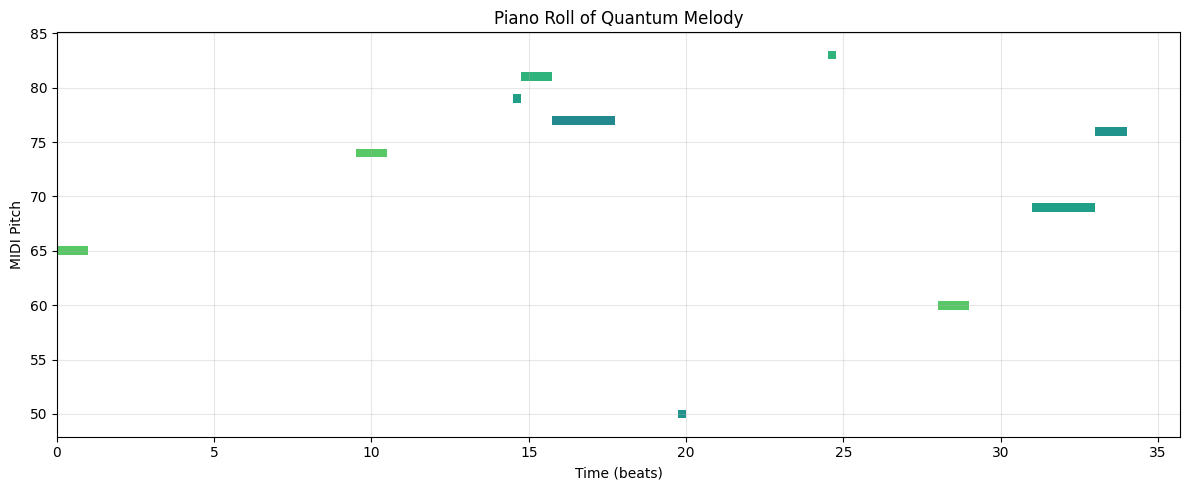

In [34]:
# Cell 19: Melody Visualization (Piano Roll)
fig, ax = plt.subplots(figsize=(12, 5))
time = 0
note_events = []
for note in melody_data:
    if not note['rest']:
        start = time
        end = time + note['duration']
        note_events.append((start, end, note['midi_pitch'], note['velocity']))
    time += note['duration']   # advance time regardless (rests take time)

# Plot piano roll
for start, end, pitch, vel in note_events:
    ax.barh(pitch, end - start, left=start, height=0.8, color=plt.cm.viridis(vel/127))

ax.set_xlabel('Time (beats)')
ax.set_ylabel('MIDI Pitch')
ax.set_title('Piano Roll of Quantum Melody')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Cell 20: Generate MIDI
def save_midi(melody, filename, tempo=TEMPO):
    """Create a MIDI file from the melody."""
    midi = MIDIFile(1)  # one track
    track = 0
    time = 0
    midi.addTempo(track, time, tempo)

    for note in melody:
        if not note['rest']:
            # Add note: track, channel, pitch, time, duration, velocity
            midi.addNote(track, 0, note['midi_pitch'], time, note['duration'], note['velocity'])
        time += note['duration']   # rests still advance time

    with open(filename, "wb") as f:
        midi.writeFile(f)
    print(f"MIDI saved as {filename}")

# Save the primary melody
midi_file = os.path.join(OUTPUT_DIR, 'quantum_melody_01.mid')
save_midi(melody_data, midi_file)

MIDI saved as outputs/quantum_melody_01.mid


In [36]:
# Cell 21: Audio Playback (convert MIDI to WAV and play)
def midi_to_wav(midi_file, wav_file):
    """Convert MIDI to WAV using FluidSynth (requires fluidsynth installed)."""
    fs = FluidSynth()
    fs.midi_to_audio(midi_file, wav_file)
    print(f"WAV saved as {wav_file}")

# Render audio
wav_file = os.path.join(OUTPUT_DIR, 'quantum_melody_01.wav')
try:
    midi_to_wav(midi_file, wav_file)
    display(Audio(wav_file))
except Exception as e:
    print(f"Audio rendering failed: {e}")
    print("You can still download the MIDI file and play it locally.")

WAV saved as outputs/quantum_melody_01.wav


## Listen to the Result

The audio you hear (if rendered) was generated from the measurement outcomes of a quantum circuit (simulated). The mapping from bits to notes is deterministic; only the bitstream originates from quantum randomness. If you are using the simulator, these are simulated quantum measurements, not physical ones.

In [19]:
# Cell 23: Generate Multiple Melodies
MELODIES_TO_GENERATE = 3

for i in range(1, MELODIES_TO_GENERATE + 1):
    # Run a fresh quantum experiment
    job = simulator.run(transpiled_circuit, shots=SHOTS)
    result = job.result()
    counts = job.result().get_counts()
    bs_list = []
    for bs, count in counts.items():
        bs_list.extend([bs] * count)
    bs_list = bs_list[:SHOTS]

    melody = generate_quantum_melody(bs_list)
    midi_path = os.path.join(OUTPUT_DIR, f'quantum_melody_{i:02d}.mid')
    save_midi(melody, midi_path)
    print(f"Generated melody {i} with {len(melody)} notes.")

MIDI saved as outputs/quantum_melody_01.mid
Generated melody 1 with 32 notes.
MIDI saved as outputs/quantum_melody_02.mid
Generated melody 2 with 32 notes.
MIDI saved as outputs/quantum_melody_03.mid
Generated melody 3 with 32 notes.


In [20]:
# Cell 24: Already covered in Cell 23 – saves multiple MIDI files.
# (This cell is kept as a placeholder to match the structure.)
print("Multiple melodies saved in the outputs directory.")

Multiple melodies saved in the outputs directory.


## Classical Comparison

For comparison, we generate a melody using Python's built‑in pseudorandom generator (`random`). The same musical mapping is used, so the only difference is the source of the bitstream. This is **not** to claim superiority of either; it simply illustrates that different stochastic processes produce different sequences.

In [21]:
# Cell 26: Classical Melody
import random
random.seed(42)   # for reproducibility

def generate_classical_bitstring(length):
    """Generate a classical pseudo‑random bitstring of given length."""
    return ''.join(str(random.randint(0, 1)) for _ in range(length))

classical_bitstrings = [generate_classical_bitstring(NUM_QUBITS) for _ in range(SHOTS)]
classical_melody = generate_quantum_melody(classical_bitstrings)  # reuses the same mapping

classical_midi = os.path.join(OUTPUT_DIR, 'classical_melody.mid')
save_midi(classical_melody, classical_midi)
print("Classical comparison melody saved.")

MIDI saved as outputs/classical_melody.mid
Classical comparison melody saved.


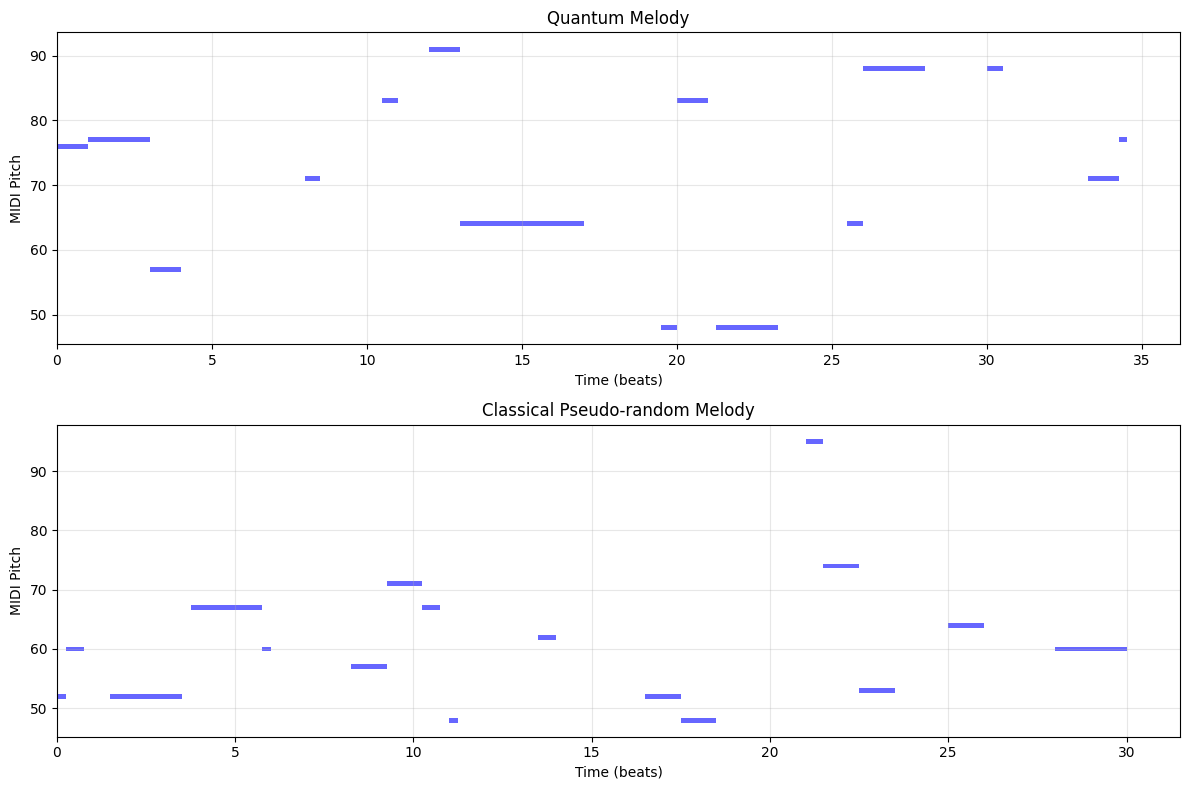

In [22]:
# Cell 27: Compare Melodies (visual)
# Show piano rolls side by side
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

def plot_melody_on_ax(ax, melody, title):
    time = 0
    for note in melody:
        if not note['rest']:
            start = time
            end = time + note['duration']
            ax.barh(note['midi_pitch'], end - start, left=start, height=0.8, color='blue', alpha=0.6)
        time += note['duration']
    ax.set_xlabel('Time (beats)')
    ax.set_ylabel('MIDI Pitch')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plot_melody_on_ax(ax1, melody_data, "Quantum Melody")
plot_melody_on_ax(ax2, classical_melody, "Classical Pseudo‑random Melody")

plt.tight_layout()
plt.show()

## What Is Actually Quantum?

It is essential to distinguish the quantum and classical parts of this experiment:

- **Quantum**: The generation of measurement outcomes from the quantum circuit (simulated by Qiskit Aer). The circuit is composed of Hadamard gates and measurements, producing a probability distribution over bitstrings.
- **Classical**: Everything else – converting bitstrings to integers, mapping integers to musical parameters, sequencing notes, generating MIDI, and rendering audio. These steps are deterministic given the bitstream.

Thus, the "quantum" contribution ends as soon as the measurement results are obtained. The music is a deterministic interpretation of those results.

## Simulator vs Real Quantum Hardware

This notebook uses a **simulator** (Qiskit Aer) that calculates the ideal probability distribution of the quantum circuit. In a real quantum processor (QPU), the measurements would be subject to noise, decoherence, and gate errors, which would alter the bitstream distribution. However, the musical mapping would remain the same.

To run on real hardware, you would need an IBM Quantum account and replace the backend with a `IBMQ.get_backend(...)`. That is beyond the scope of this experiment, but the code is designed to be hardware‑agnostic.